# DeepPack3D — BLSF Packing Demo

Uses the **Best Longest Side Fit (BLSF)** heuristic with lookahead = 1 to pack a set of articles into a configurable bin.  
Articles are permitted to rotate around the **z-axis** (swaps width ↔ depth while keeping height constant, so items remain upright).

## 1. Import Required Libraries

In [18]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))  # ensure deeppack3d modules are on the path

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from env import MultiBinPackerEnv
from conveyor import Conveyor
from agent import HeuristicAgent, best_long_side_fit

print("Imports OK")

Imports OK


## 2. Define Bin Dimensions

Set the bin `(width, height, depth)`. Modify these three variables to change the bin size.

In [ ]:
# ── Bin configuration ────────────────────────────────────────────────────────
BIN_WIDTH  = 32   # x-dimension
BIN_HEIGHT = 32   # y-dimension (vertical / stacking direction)
BIN_DEPTH  = 32   # z-dimension

BIN_SIZE = (BIN_WIDTH, BIN_HEIGHT, BIN_DEPTH)
print(f"Bin size: {BIN_SIZE}")

Bin size: (32, 32, 32)


In [ ]:
2   # x-dimension
BIN_HEIGHT = 32   # y-dimension (vertical / stacking direction)
BIN_DEPTH  = 32   # z-dimension

BIN_SIZE = (BIN_WIDTH, BIN_HEIGHT, BIN_DEPTH)
print(f"Bin size: {BIN_SIZE}")

## 3. Define Articles (Items to Pack)

A sample dictionary of 50 articles taken directly from `input.txt`.  
Each entry maps a label to its `(width, height, depth)` dimensions.  
Edit or extend the dictionary to change which items are packed.

In [20]:
# ── Articles dictionary: label -> (width, height, depth) ─────────────────────
# Dimensions are taken from input.txt (all 50 lines).
articles = {
    "article_01": (6,  9,  8),
    "article_02": (6,  7,  8),
    "article_03": (7,  7, 10),
    "article_04": (8,  7, 10),
    "article_05": (8,  7,  8),
    "article_06": (7,  7, 10),
    "article_07": (10, 7,  6),
    "article_08": (12, 8,  8),
    "article_09": (7,  7,  6),
    "article_10": (10, 8, 10),
    "article_11": (11, 7,  8),
    "article_12": (6,  7,  6),
    "article_13": (8,  7,  8),
    "article_14": (9,  7,  6),
    "article_15": (6,  7,  8),
    "article_16": (7,  7,  8),
    "article_17": (9,  9,  8),
    "article_18": (11, 9, 11),
    "article_19": (6,  9,  8),
    "article_20": (7,  9,  6),
    "article_21": (9,  9,  6),
    "article_22": (6,  6,  6),
    "article_23": (6,  9,  7),
    "article_24": (10, 9,  7),
    "article_25": (6,  6,  9),
    "article_26": (10, 9,  6),
    "article_27": (10, 9,  8),
    "article_28": (7,  8,  9),
    "article_29": (10, 8,  7),
    "article_30": (10, 8, 11),
    "article_31": (6,  7,  8),
    "article_32": (6,  9,  6),
    "article_33": (6,  9,  9),
    "article_34": (7,  6, 11),
    "article_35": (10, 6, 11),
    "article_36": (11, 6,  6),
    "article_37": (9,  6,  6),
    "article_38": (10, 7,  6),
    "article_39": (6,  6, 11),
    "article_40": (6,  6,  6),
    "article_41": (12, 7,  6),
    "article_42": (9,  6, 11),
    "article_43": (7,  6,  9),
    "article_44": (9,  6,  9),
    "article_45": (10, 6,  6),
    "article_46": (10, 6,  9),
    "article_47": (11, 10, 9),
    "article_48": (10, 10, 8),
    "article_49": (7,  10, 9),
    "article_50": (7,  10, 10),
}

print(f"{len(articles)} articles defined.")
for label, dims in list(articles.items())[:5]:
    print(f"  {label}: w={dims[0]}, h={dims[1]}, d={dims[2]}")

50 articles defined.
  article_01: w=6, h=9, d=8
  article_02: w=6, h=7, d=8
  article_03: w=7, h=7, d=10
  article_04: w=8, h=7, d=10
  article_05: w=8, h=7, d=8


## 4. Configure BLSF Packer with Lookahead = 1

- **Method**: Best Longest Side Fit (`blsf`) — picks the placement that maximises the longest remaining side of the free split.  
- **Lookahead**: 1 — only the next item on the conveyor is considered.  
- **Rotation**: `'y'` — each article may be rotated around the vertical (z) axis (swaps `width` ↔ `depth`, keeps `height` constant so items remain upright).

In [21]:
LOOKAHEAD = 1   # number of upcoming items visible to the heuristic

# Convert the articles dict to an ordered list of (w, h, d) tuples for the conveyor
item_list = list(articles.values())

# Build a Conveyor that replays the fixed item list instead of generating random items
conveyor = Conveyor(k=LOOKAHEAD, assigned_items=item_list)

# Build the environment
#   use_rotate='y'  → rotate around vertical axis only (swaps w ↔ d, h stays fixed — items remain upright)
#   use_skip=True   → heuristic may inspect any of the k visible items
env = MultiBinPackerEnv(
    n_bins=1,
    max_bins=1,
    size=BIN_SIZE,
    k=LOOKAHEAD,
    use_rotate='y',
    verbose=False,
)
env.conveyor = conveyor.reset()

# Wrap with the BLSF heuristic agent
agent = HeuristicAgent(best_long_side_fit, env, verbose=True)

print(f"BLSF packer ready — bin {BIN_SIZE}, lookahead={LOOKAHEAD}, rotation='y' (w↔d, upright)")

BLSF packer ready — bin (32, 32, 32), lookahead=1, rotation='y' (w↔d, upright)


## 5. Run Packing and Visualize Results

In [24]:
labels = list(articles.keys())
placements = []   # (label, (x,y,z), (w,h,d))
label_idx = 0

for result in agent.run(max_ep=1, verbose=False):
    if result is None:
        # episode boundary — conveyor exhausted or bin full
        break
    _, (x, y, z), (w, h, d), _ = result
    label = labels[label_idx] if label_idx < len(labels) else f"item_{label_idx}"
    placements.append((label, (x, y, z), (w, h, d)))
    label_idx += 1

print(f"\nPacked {len(placements)} articles into 1 bin.")
print(f"\n{'Article':<14} {'Origin (x,y,z)':<20} {'Size (w,h,d)'}")
print("-" * 55)
for label, (x, y, z), (w, h, d) in placements:
    orig_dims = articles[label]
    rotated   = orig_dims != (w, h, d)
    rot_tag   = " [rotated]" if rotated else ""
    print(f"{label:<14} ({x:>2},{y:>2},{z:>2})              ({w},{h},{d}){rot_tag}")


Packed 39 articles into 1 bin.

Article        Origin (x,y,z)       Size (w,h,d)
-------------------------------------------------------
article_01     ( 0, 0, 0)              (8,9,6) [rotated]
article_02     ( 0, 9, 0)              (8,7,6) [rotated]
article_03     ( 0,16, 0)              (10,7,7) [rotated]
article_04     ( 0,23, 0)              (10,7,8) [rotated]
article_05     ( 0, 0, 8)              (8,7,8)
article_06     ( 0, 7, 8)              (10,7,7) [rotated]
article_07     ( 0,14, 8)              (10,7,6)
article_08     ( 0,21, 8)              (12,8,8)
article_09     (12, 0, 0)              (7,7,6)
article_10     (12, 0, 6)              (10,8,10)
article_11     ( 0, 0,16)              (11,7,8)
article_12     (12, 7, 0)              (6,7,6)
article_13     (12,14, 0)              (8,7,8)
article_14     (12,21, 0)              (9,7,6)
article_15     (21, 0, 0)              (8,7,6) [rotated]
article_16     (12, 8, 8)              (7,7,8)
article_17     (12,15, 8)              (9,

Space utilisation: 58.1%  (39/50 articles packed)


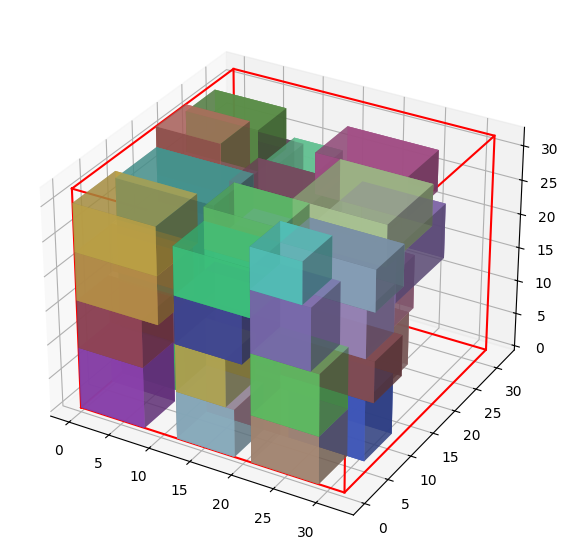

In [25]:
from IPython.display import display

packed_vol  = sum(w * h * d for _, _, (w, h, d) in placements)
bin_vol     = BIN_WIDTH * BIN_HEIGHT * BIN_DEPTH
utilisation = packed_vol / bin_vol * 100
print(f"Space utilisation: {utilisation:.1f}%  ({len(placements)}/{len(articles)} articles packed)")

fig = env.packers[0].render()
fig.set_size_inches(8, 7)
display(fig)